In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from sklearn.metrics import mean_absolute_error, mean_squared_error
from models import *
from plots import *

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
data = load_data()

In [4]:
data.head()

,date,tmax,tmin,tmed,month,year,prec,tdiff,log_diff,lagged_tdiff_1,...,lagged_tdiff_12,lagged_prec_12,lagged_tmed_12,lagged_tmax_12,lagged_tmin_12,lagged_tdiff_24,lagged_prec_24,lagged_tmed_24,lagged_tmax_24,lagged_tmin_24
date,,,,,,,,,,,,,,,,,,,,,
1994-01-01,1994-01-01,13.08,4.59,8.84,1,1994,145.2,8.49,2.138889,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994-02-01,1994-02-01,13.51,4.71,9.11,2,1994,130.6,8.80,2.174752,8.49,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994-03-01,1994-03-01,19.63,8.29,13.96,3,1994,11.1,11.34,2.428336,8.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994-04-01,1994-04-01,18.54,7.25,12.89,4,1994,43.2,11.29,2.423917,11.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994-05-01,1994-05-01,20.15,10.77,15.46,5,1994,160.2,9.38,2.238580,11.29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
target = 't_seasdiff'
exog=['lagged_tmed_24', 'lagged_prec_24', 'lagged_tmin_24', 'lagged_tmax_24']

In [6]:
data.head()

,date,tmax,tmin,tmed,month,year,prec,tdiff,log_diff,lagged_tdiff_1,...,lagged_tdiff_12,lagged_prec_12,lagged_tmed_12,lagged_tmax_12,lagged_tmin_12,lagged_tdiff_24,lagged_prec_24,lagged_tmed_24,lagged_tmax_24,lagged_tmin_24
date,,,,,,,,,,,,,,,,,,,,,
1994-01-01,1994-01-01,13.08,4.59,8.84,1,1994,145.2,8.49,2.138889,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994-02-01,1994-02-01,13.51,4.71,9.11,2,1994,130.6,8.80,2.174752,8.49,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994-03-01,1994-03-01,19.63,8.29,13.96,3,1994,11.1,11.34,2.428336,8.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994-04-01,1994-04-01,18.54,7.25,12.89,4,1994,43.2,11.29,2.423917,11.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994-05-01,1994-05-01,20.15,10.77,15.46,5,1994,160.2,9.38,2.238580,11.29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
if target == 't_seasdiff':
    data["t_seasdiff"]= data["tdiff"].diff(24)
    data = data.dropna(subset=["t_seasdiff"])

# SARIMA / SARIMAX

In [8]:
len(data)

289

In [9]:
p, d, q = 0, 1, 1
P, D, Q, s = 1, 0, 0, 12


In [10]:
rmse, mae, results, forecast, test, train = sarimax_experiment(data, target, p, d, q, P, D, Q, s)

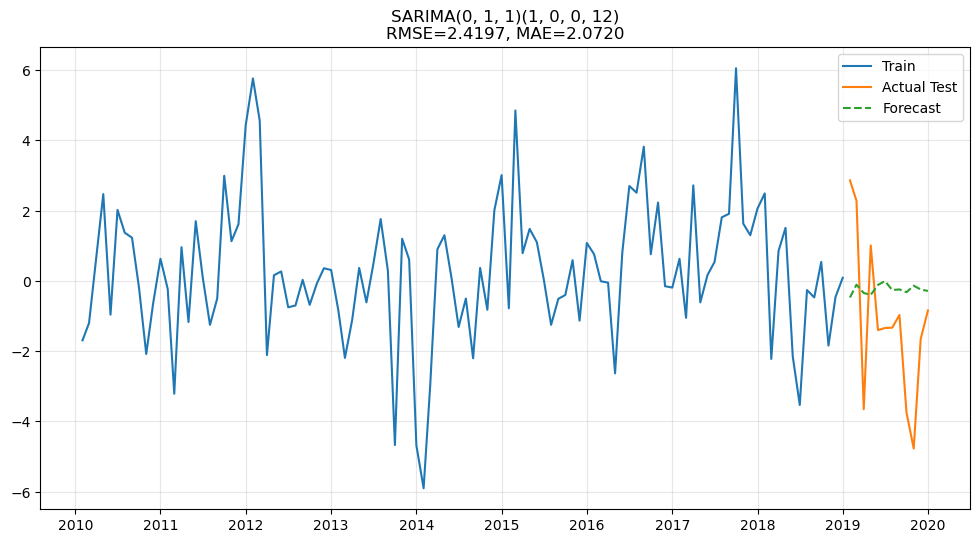

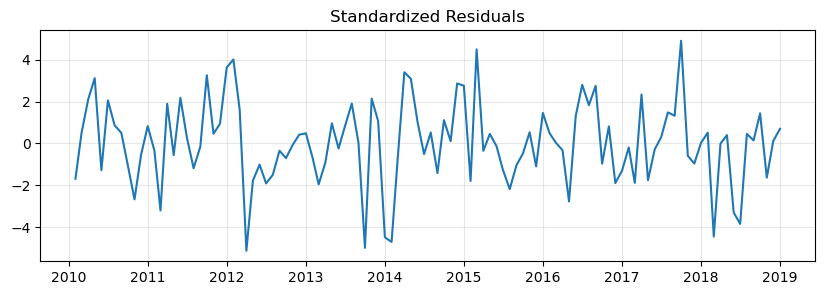

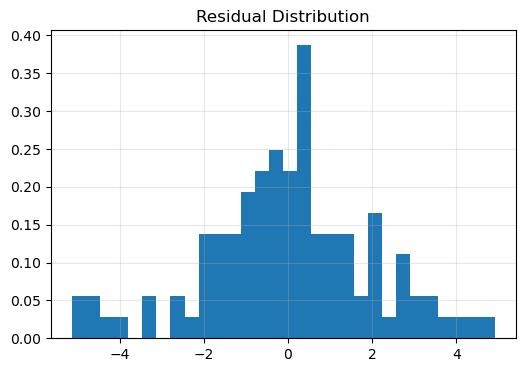

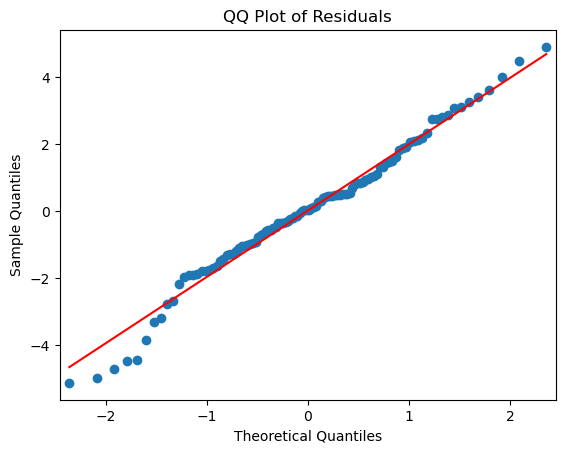

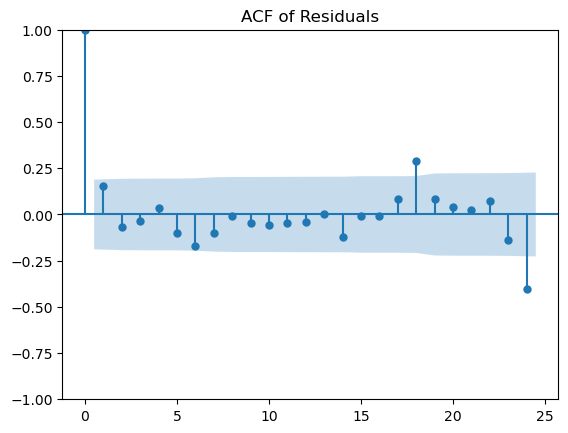

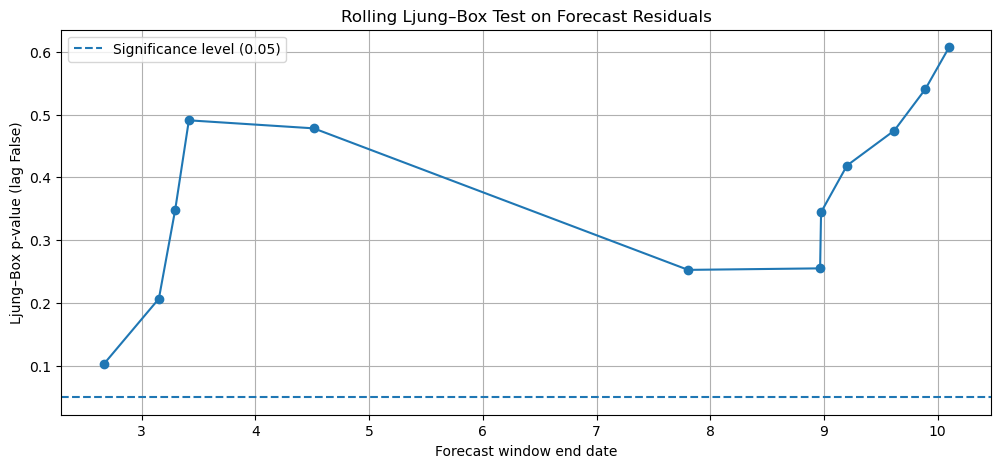

In [11]:
plot_sarimax_results(
    train=train,
    test=test,
    forecast=forecast,
    results=results,
    order=(p,d,q),
    seasonal_order=(P,D,Q,12),
    rmse=rmse,
    mae=mae,
)

In [12]:
rmse, mae, results, forecast, test, train = sarimax_experiment(data, target, p, d, q, P, D, Q, s, exog= exog)

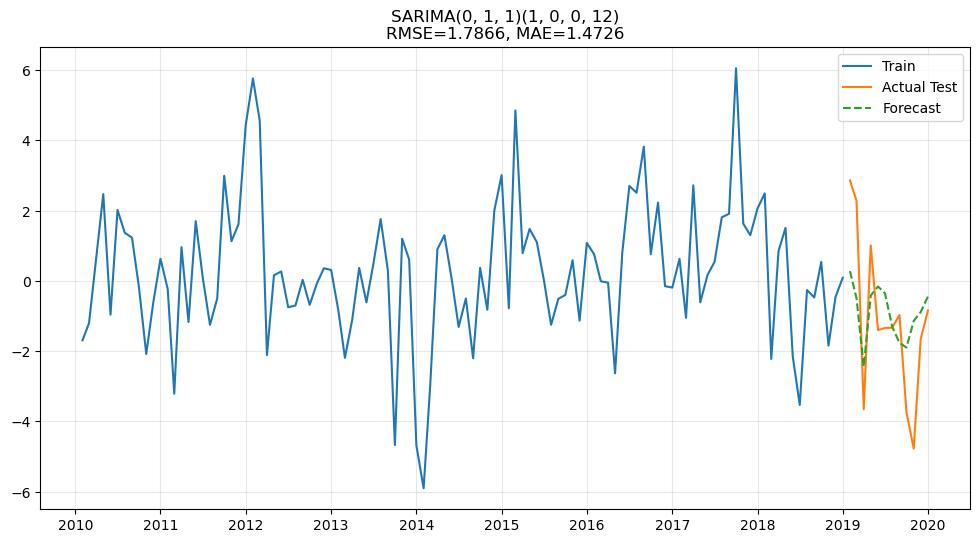

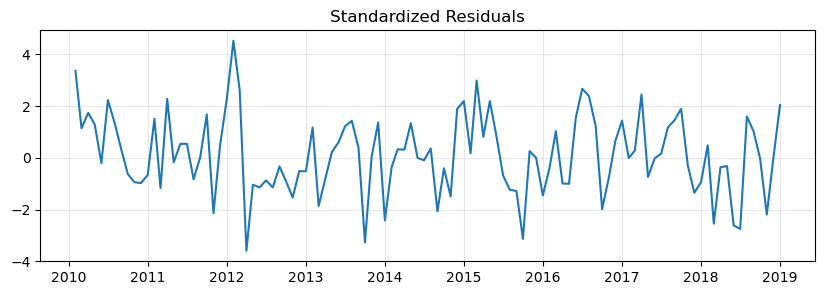

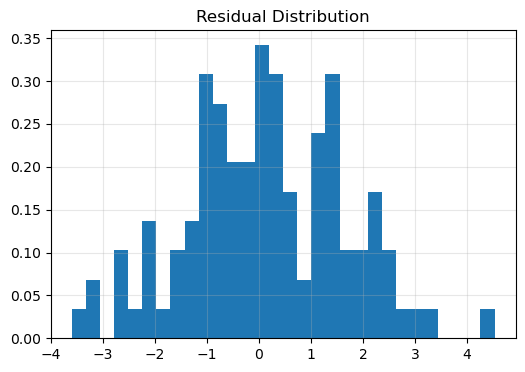

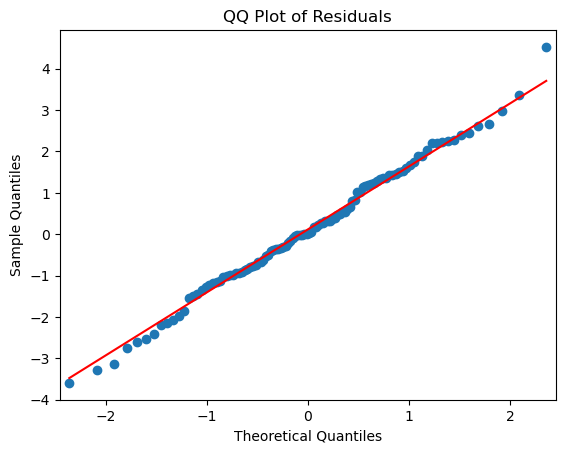

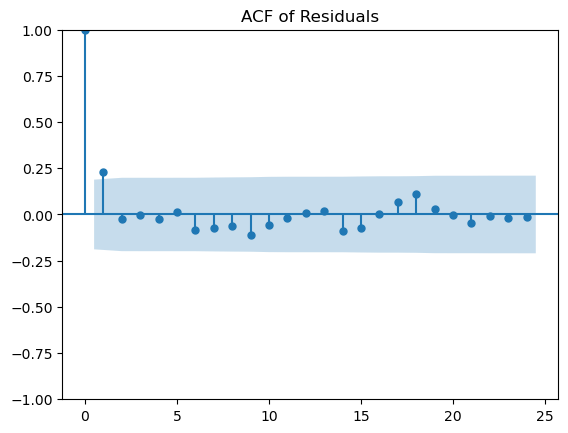

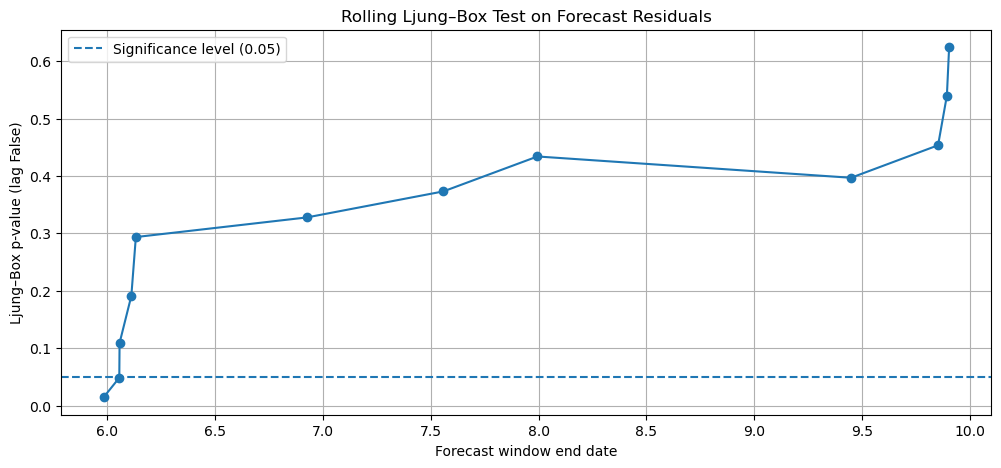

In [13]:
plot_sarimax_results(
    train=train,
    test=test,
    forecast=forecast,
    results=results,
    order=(p,d,q),
    seasonal_order=(P,D,Q,12),
    rmse=rmse,
    mae=mae,
)

In [14]:
from utils import sarima_candidates_from_acf

cand_res = sarima_candidates_from_acf(data[target], m=12, max_p=3, max_q=2, max_P=3, max_Q=3, max_lag=50)

candidates = cand_res["candidates"]
for i, (p, d, q, P, D, Q, s) in enumerate(candidates, 1):
    print(f"{i:02d}. SARIMA({p},{d},{q})({P},{D},{Q},{s})")

n: 289
NaNs: 0
var: 3.8377627470935463
01. SARIMA(0,0,0)(0,0,0,12)
02. SARIMA(0,0,0)(0,0,2,12)
03. SARIMA(0,0,0)(2,0,0,12)
04. SARIMA(0,0,0)(2,0,2,12)
05. SARIMA(0,0,1)(0,0,0,12)
06. SARIMA(0,0,1)(0,0,2,12)
07. SARIMA(0,0,1)(2,0,0,12)
08. SARIMA(0,0,1)(2,0,2,12)
09. SARIMA(0,0,2)(0,0,0,12)
10. SARIMA(0,0,2)(0,0,2,12)
11. SARIMA(0,0,2)(2,0,0,12)
12. SARIMA(0,0,2)(2,0,2,12)
13. SARIMA(1,0,0)(0,0,0,12)
14. SARIMA(1,0,0)(0,0,2,12)
15. SARIMA(1,0,0)(2,0,0,12)
16. SARIMA(1,0,0)(2,0,2,12)
17. SARIMA(1,0,1)(0,0,0,12)
18. SARIMA(1,0,1)(0,0,2,12)
19. SARIMA(1,0,1)(2,0,0,12)
20. SARIMA(1,0,1)(2,0,2,12)
21. SARIMA(1,0,2)(0,0,0,12)
22. SARIMA(1,0,2)(0,0,2,12)
23. SARIMA(1,0,2)(2,0,0,12)
24. SARIMA(1,0,2)(2,0,2,12)


In [15]:
best_info, scores_df = sarimax_grid_search(
    df=data,
    target=target,
    candidates=candidates,
    forecast_window=12,
    no_windows=10,
    exog=None,    # or list of exogenous column names
    metric="rmse",
    verbose=True,
)

Tried SARIMA(0,0,0)(0,0,0,12) -> RMSE=2.4892, MAE=2.1533
Tried SARIMA(0,0,0)(0,0,2,12) -> RMSE=1.4948, MAE=1.1681
Tried SARIMA(0,0,0)(2,0,0,12) -> RMSE=1.9211, MAE=1.5007
Tried SARIMA(0,0,0)(2,0,2,12) -> RMSE=1.5419, MAE=1.1916
Tried SARIMA(0,0,1)(0,0,0,12) -> RMSE=2.4881, MAE=2.1523
Tried SARIMA(0,0,1)(0,0,2,12) -> RMSE=1.3822, MAE=1.0886
Tried SARIMA(0,0,1)(2,0,0,12) -> RMSE=1.9410, MAE=1.5272
Tried SARIMA(0,0,1)(2,0,2,12) -> RMSE=1.4478, MAE=1.1658
Tried SARIMA(0,0,2)(0,0,0,12) -> RMSE=2.4791, MAE=2.1440
Tried SARIMA(0,0,2)(0,0,2,12) -> RMSE=1.3542, MAE=1.0730
Tried SARIMA(0,0,2)(2,0,0,12) -> RMSE=1.9277, MAE=1.5167
Tried SARIMA(0,0,2)(2,0,2,12) -> RMSE=1.4365, MAE=1.1686
Tried SARIMA(1,0,0)(0,0,0,12) -> RMSE=2.4859, MAE=2.1502
Tried SARIMA(1,0,0)(0,0,2,12) -> RMSE=1.3386, MAE=1.0666
Tried SARIMA(1,0,0)(2,0,0,12) -> RMSE=1.9311, MAE=1.5183
Tried SARIMA(1,0,0)(2,0,2,12) -> RMSE=1.4260, MAE=1.1663
Tried SARIMA(1,0,1)(0,0,0,12) -> RMSE=2.4913, MAE=2.1555
Tried SARIMA(1,0,1)(0,0,2,12) -

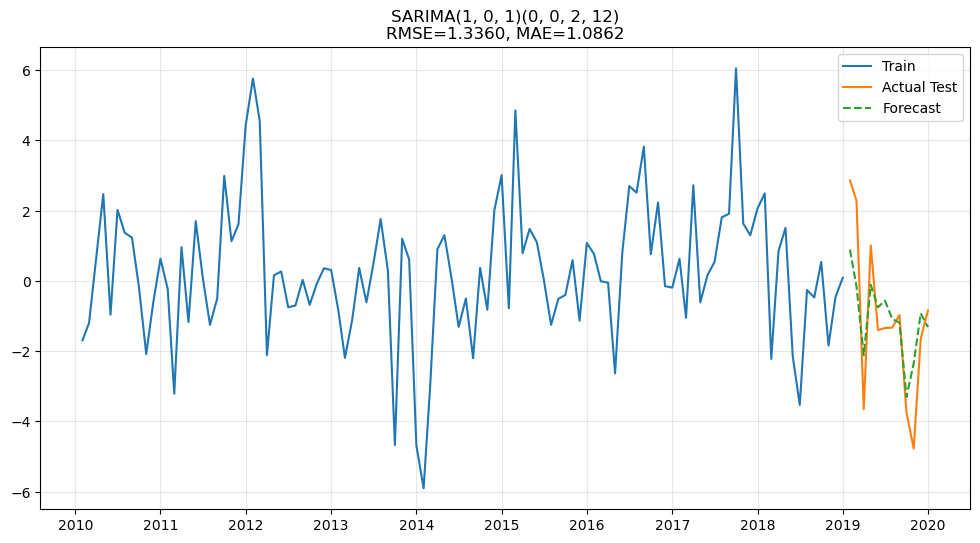

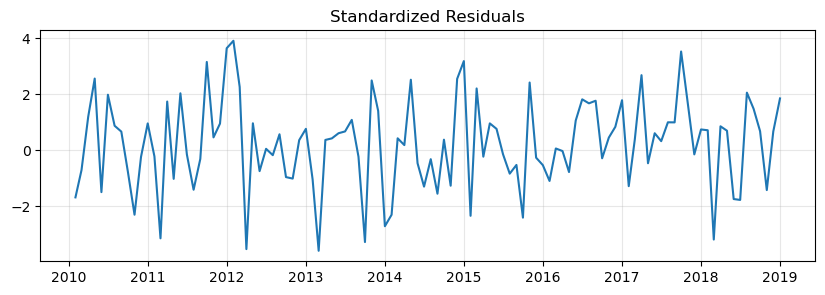

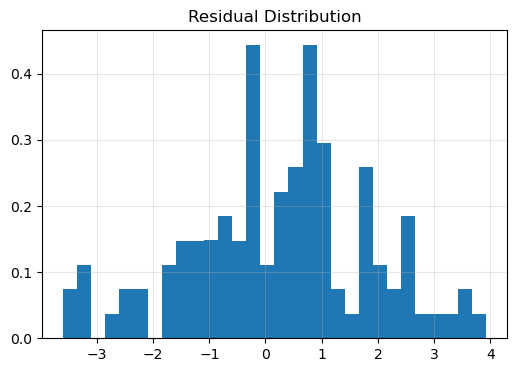

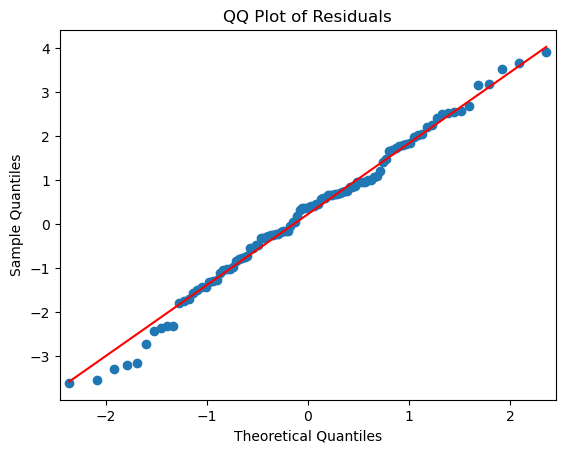

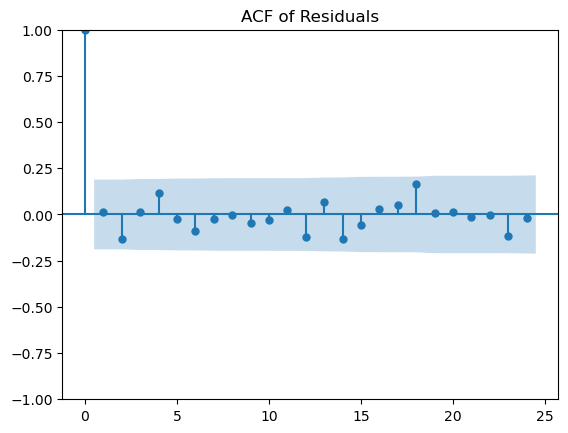

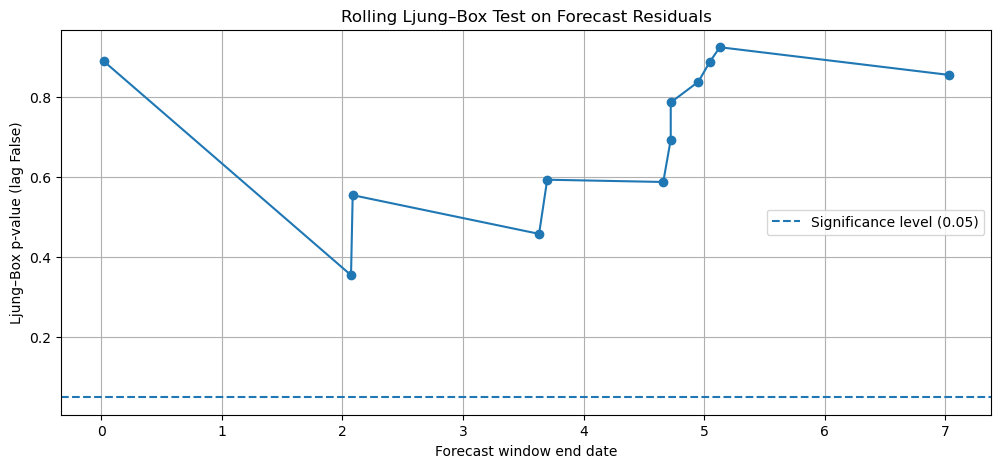

In [16]:
plot_sarimax_results(
    train=best_info["train"],
    test=best_info["test"],
    forecast=best_info["forecast"],
    results=best_info["results"],
    order=best_info["order"],
    seasonal_order=best_info["seasonal_order"],
    rmse=best_info["rmse"],
    mae=best_info["mae"],
)

In [17]:
best_info, scores_df = sarimax_grid_search(
    df=data,
    target=target,
    candidates=candidates,
    forecast_window=12,
    no_windows=10,
    exog=None,    
    metric="rmse",
    verbose=True,
)

Tried SARIMA(0,0,0)(0,0,0,12) -> RMSE=2.4892, MAE=2.1533
Tried SARIMA(0,0,0)(0,0,2,12) -> RMSE=1.4948, MAE=1.1681
Tried SARIMA(0,0,0)(2,0,0,12) -> RMSE=1.9211, MAE=1.5007
Tried SARIMA(0,0,0)(2,0,2,12) -> RMSE=1.5419, MAE=1.1916
Tried SARIMA(0,0,1)(0,0,0,12) -> RMSE=2.4881, MAE=2.1523
Tried SARIMA(0,0,1)(0,0,2,12) -> RMSE=1.3822, MAE=1.0886
Tried SARIMA(0,0,1)(2,0,0,12) -> RMSE=1.9410, MAE=1.5272
Tried SARIMA(0,0,1)(2,0,2,12) -> RMSE=1.4478, MAE=1.1658
Tried SARIMA(0,0,2)(0,0,0,12) -> RMSE=2.4791, MAE=2.1440
Tried SARIMA(0,0,2)(0,0,2,12) -> RMSE=1.3542, MAE=1.0730
Tried SARIMA(0,0,2)(2,0,0,12) -> RMSE=1.9277, MAE=1.5167
Tried SARIMA(0,0,2)(2,0,2,12) -> RMSE=1.4365, MAE=1.1686
Tried SARIMA(1,0,0)(0,0,0,12) -> RMSE=2.4859, MAE=2.1502
Tried SARIMA(1,0,0)(0,0,2,12) -> RMSE=1.3386, MAE=1.0666
Tried SARIMA(1,0,0)(2,0,0,12) -> RMSE=1.9311, MAE=1.5183
Tried SARIMA(1,0,0)(2,0,2,12) -> RMSE=1.4260, MAE=1.1663
Tried SARIMA(1,0,1)(0,0,0,12) -> RMSE=2.4913, MAE=2.1555
Tried SARIMA(1,0,1)(0,0,2,12) -

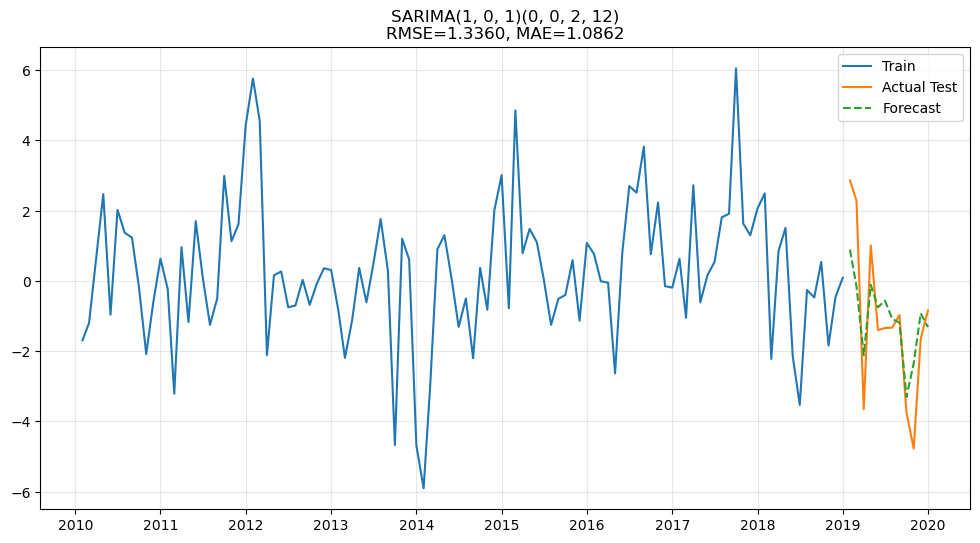

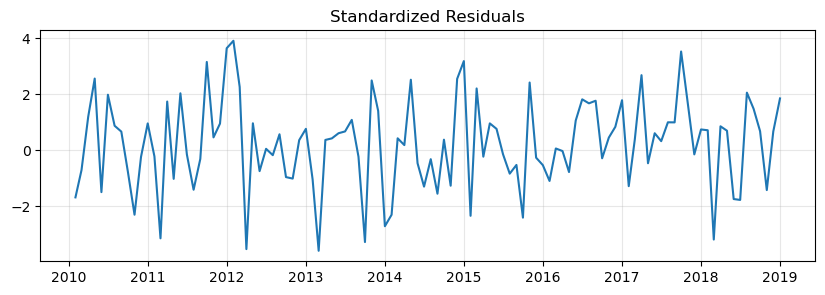

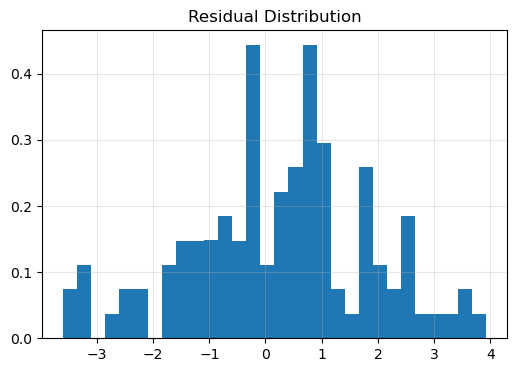

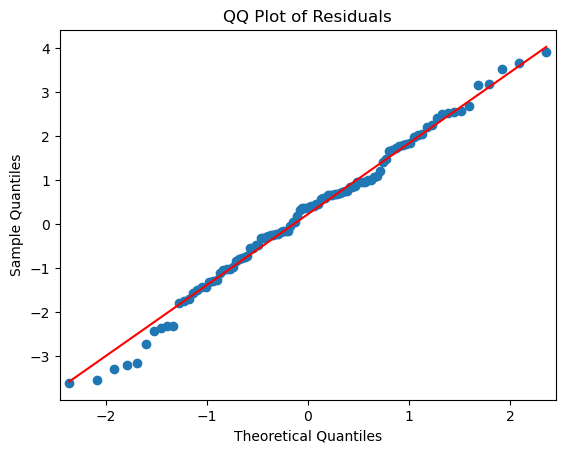

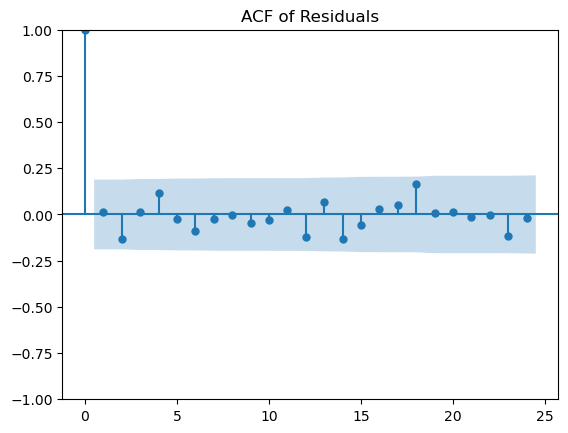

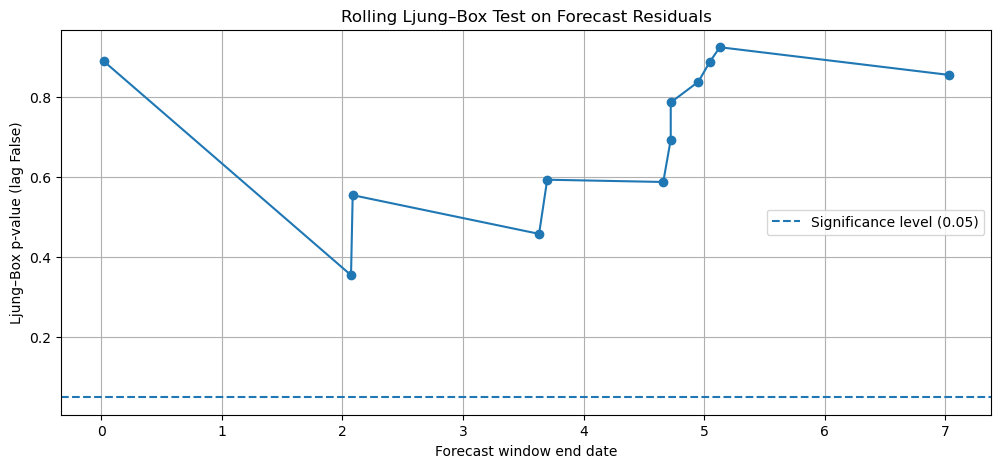

In [18]:
plot_sarimax_results(
    train=train,
    test=best_info["test"],
    forecast=best_info["forecast"],
    results=best_info["results"],
    order=best_info["order"],
    seasonal_order=best_info["seasonal_order"],
    rmse=best_info["rmse"],
    mae=best_info["mae"],
)

In [19]:
best_info, scores_df = sarimax_grid_search(
    df=data,
    target=target,
    candidates=candidates,
    forecast_window=12,
    no_windows=10,
    exog=exog,    # or list of exogenous column names
    metric="rmse",
    verbose=True,
)

Tried SARIMA(0,0,0)(0,0,0,12) -> RMSE=1.8417, MAE=1.5165
Tried SARIMA(0,0,0)(0,0,2,12) -> RMSE=1.8265, MAE=1.4357
Tried SARIMA(0,0,0)(2,0,0,12) -> RMSE=1.8169, MAE=1.4868
Tried SARIMA(0,0,0)(2,0,2,12) -> RMSE=1.8647, MAE=1.4546
Tried SARIMA(0,0,1)(0,0,0,12) -> RMSE=1.7959, MAE=1.4716
Tried SARIMA(0,0,1)(0,0,2,12) -> RMSE=1.8383, MAE=1.4317
Tried SARIMA(0,0,1)(2,0,0,12) -> RMSE=1.8000, MAE=1.4717
Tried SARIMA(0,0,1)(2,0,2,12) -> RMSE=1.8801, MAE=1.4662
Tried SARIMA(0,0,2)(0,0,0,12) -> RMSE=1.7600, MAE=1.4431
Tried SARIMA(0,0,2)(0,0,2,12) -> RMSE=1.8371, MAE=1.4267
Tried SARIMA(0,0,2)(2,0,0,12) -> RMSE=1.7657, MAE=1.4481
Tried SARIMA(0,0,2)(2,0,2,12) -> RMSE=1.8661, MAE=1.4576
Tried SARIMA(1,0,0)(0,0,0,12) -> RMSE=1.7666, MAE=1.4497
Tried SARIMA(1,0,0)(0,0,2,12) -> RMSE=1.7437, MAE=1.3630
Tried SARIMA(1,0,0)(2,0,0,12) -> RMSE=1.7565, MAE=1.4427
Tried SARIMA(1,0,0)(2,0,2,12) -> RMSE=1.8179, MAE=1.4355
Tried SARIMA(1,0,1)(0,0,0,12) -> RMSE=1.7685, MAE=1.4504
Tried SARIMA(1,0,1)(0,0,2,12) -

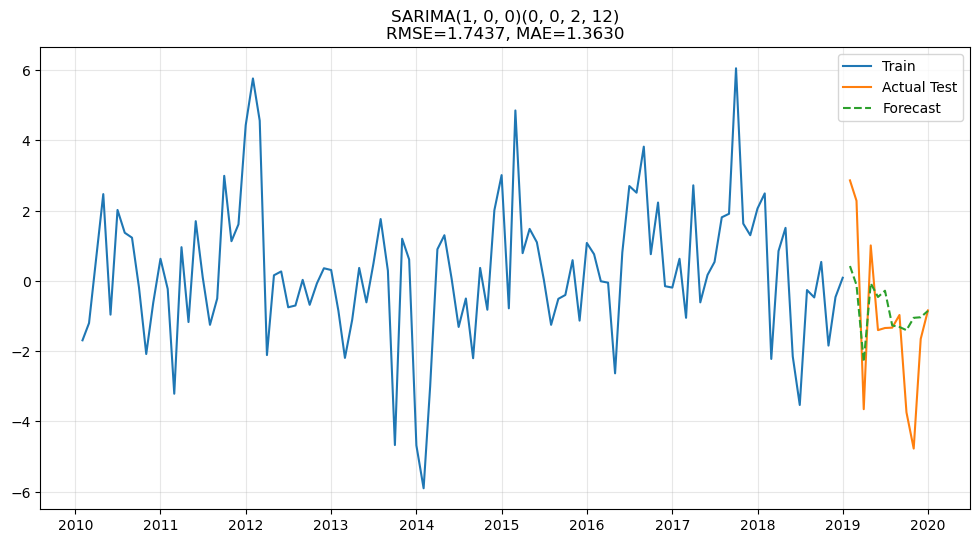

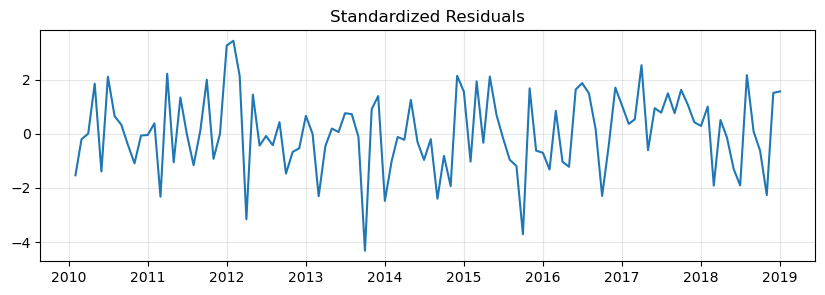

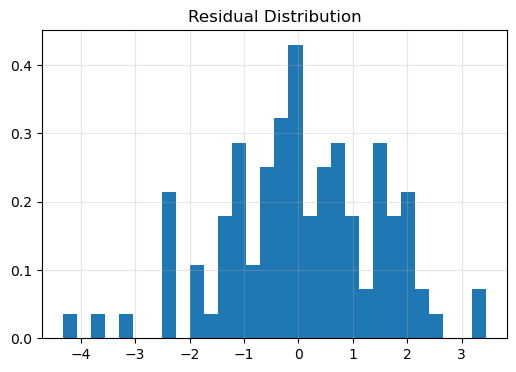

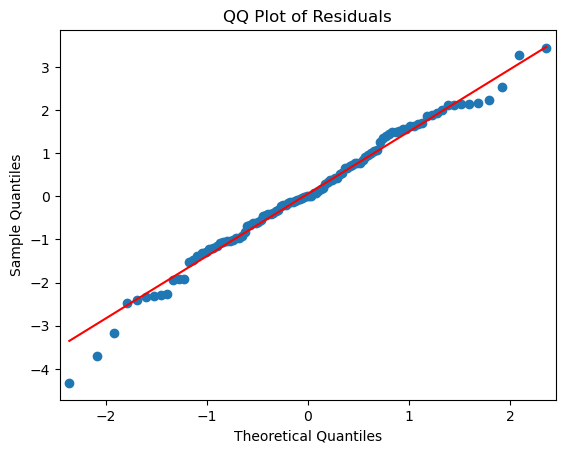

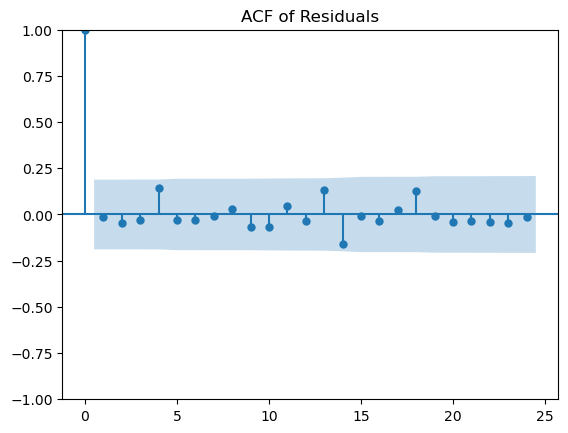

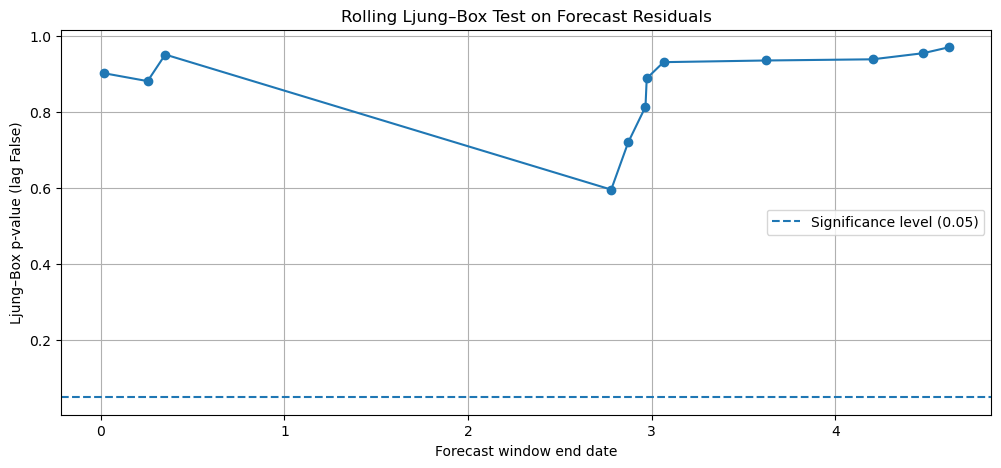

In [20]:
plot_sarimax_results(
    train=best_info["train"],
    test=best_info["test"],
    forecast=best_info["forecast"],
    results=best_info["results"],
    order=best_info["order"],
    seasonal_order=best_info["seasonal_order"],
    rmse=best_info["rmse"],
    mae=best_info["mae"],
)

## Using AutoSarima with the current train/test split

In [21]:
rmse, mae, results, forecast, test, train, order, seasonal_order = auto_sarima_experiment(data, target, forecast_window=12, no_windows=10, m=12)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=457.784, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=448.829, Time=0.04 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=446.652, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=457.624, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=448.816, Time=0.01 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=inf, Time=0.12 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=inf, Time=0.15 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=449.942, Time=0.02 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=inf, Time=0.19 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=455.354, Time=0.02 sec
 ARIMA(1,0,1)(0,0,1)[12] intercept   : AIC=448.270, Time=0.04 sec
 ARIMA(0,0,2)(0,0,1)[12] intercept   : AIC=448.352, Time=0.03 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=446.344, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=447.422, Time=0.01 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=in

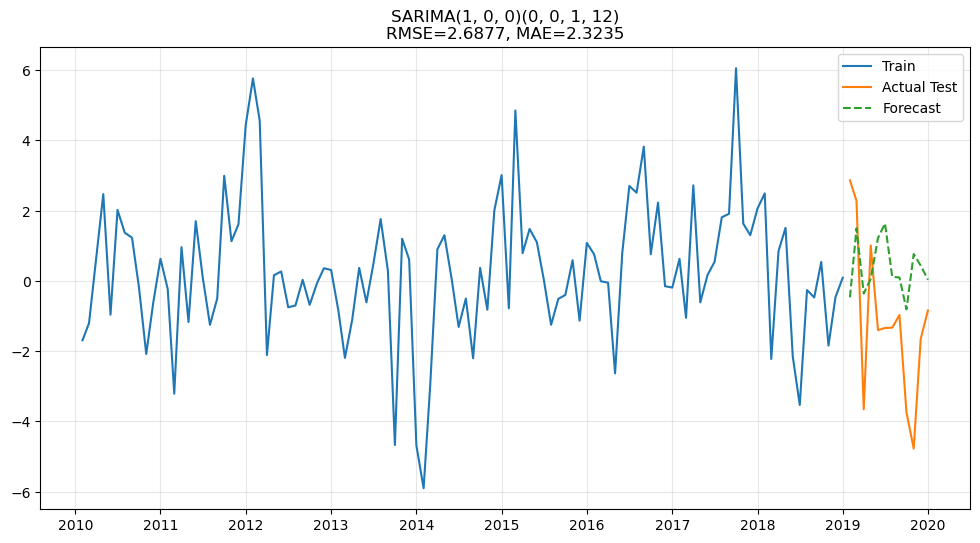

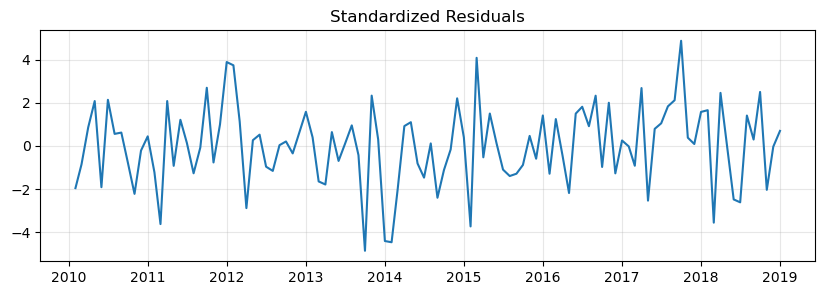

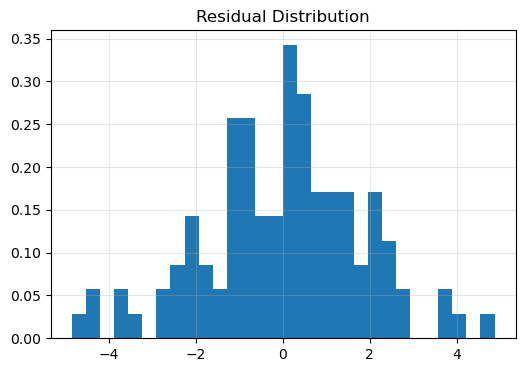

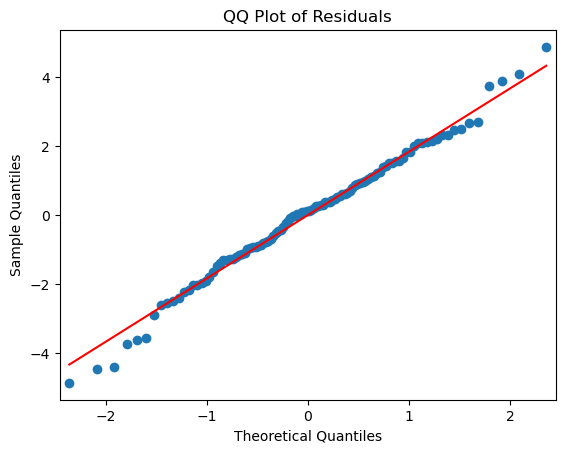

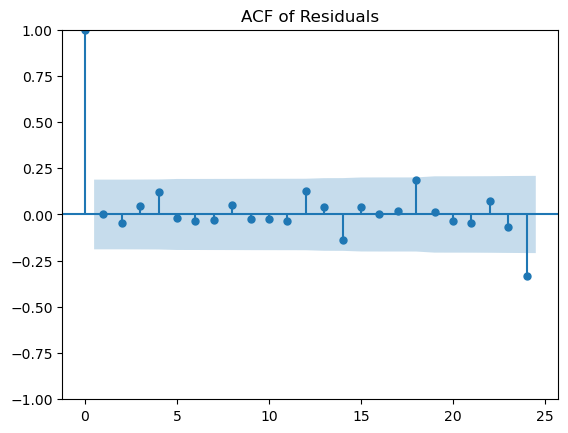

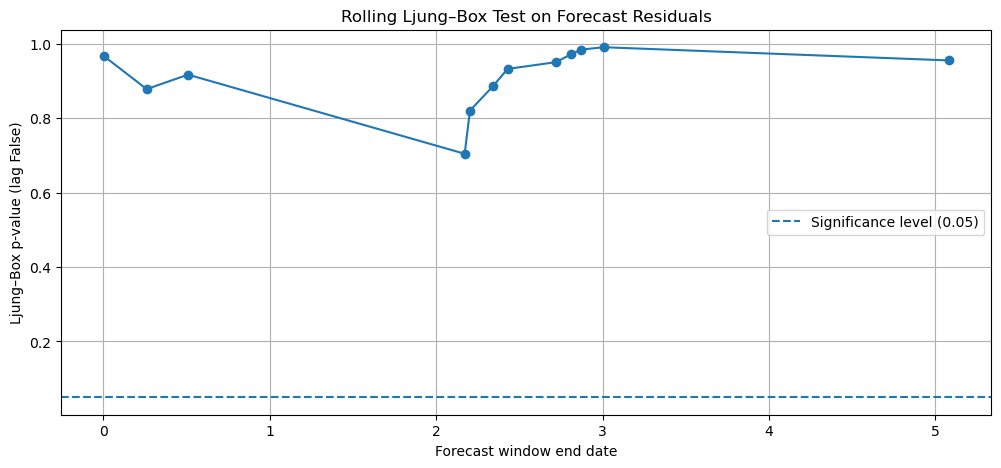

In [22]:
plot_sarimax_results(
    train=train,
    test=test,
    forecast=forecast,
    results=results,
    order=order,
    seasonal_order=seasonal_order,
    rmse=rmse,
    mae=mae,
)

In [23]:
rmse, mae, results, forecast, test, train, order, seasonal_order = auto_sarima_experiment(data, target, forecast_window=12, no_windows=10, m=12, exog=exog)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=457.784, Time=0.00 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=448.829, Time=0.05 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=446.652, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=457.624, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=448.816, Time=0.01 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=inf, Time=0.12 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=inf, Time=0.14 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=449.942, Time=0.04 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=inf, Time=0.19 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=455.354, Time=0.02 sec
 ARIMA(1,0,1)(0,0,1)[12] intercept   : AIC=448.270, Time=0.04 sec
 ARIMA(0,0,2)(0,0,1)[12] intercept   : AIC=448.352, Time=0.03 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=446.344, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=447.422, Time=0.01 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=in

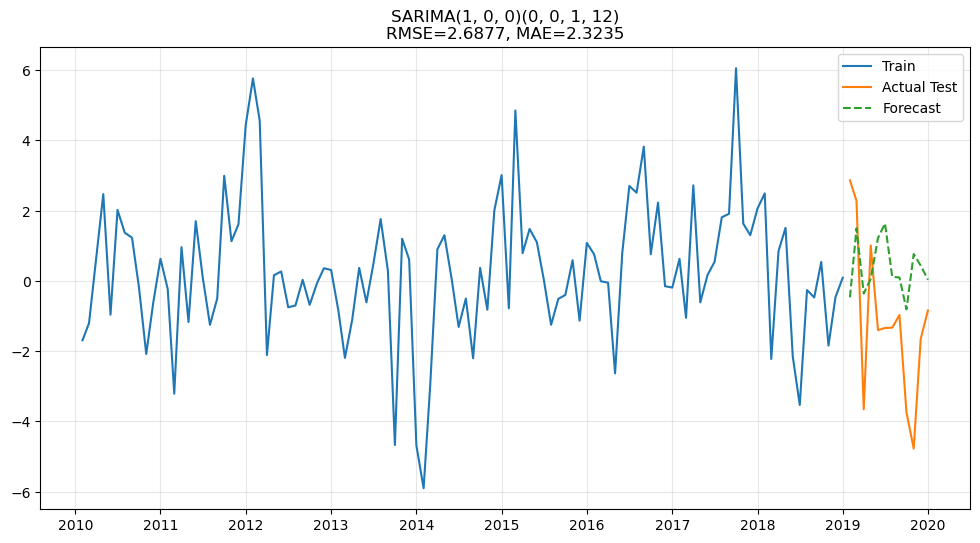

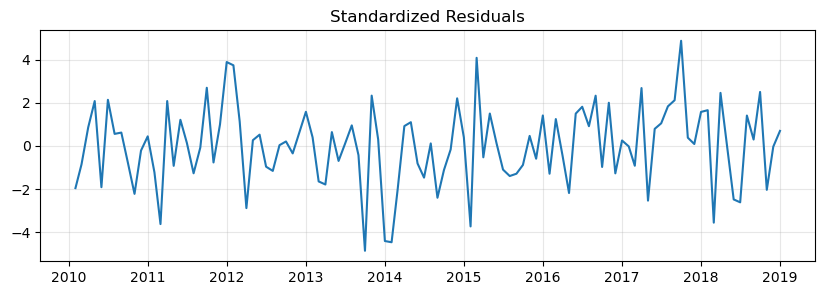

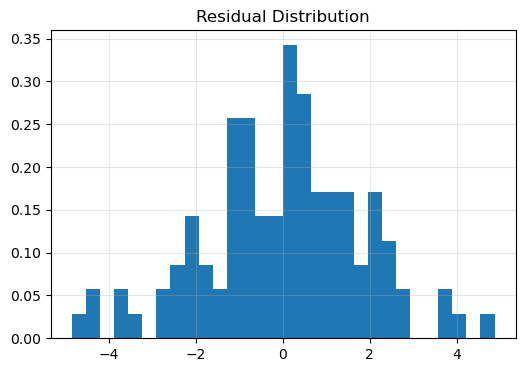

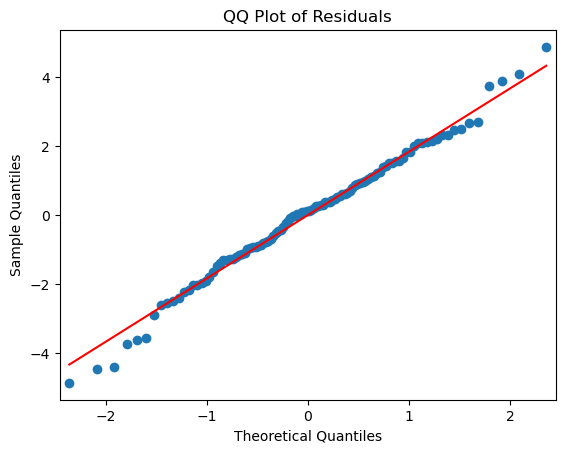

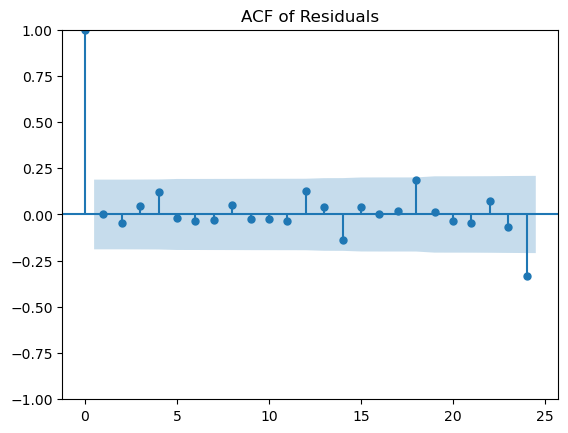

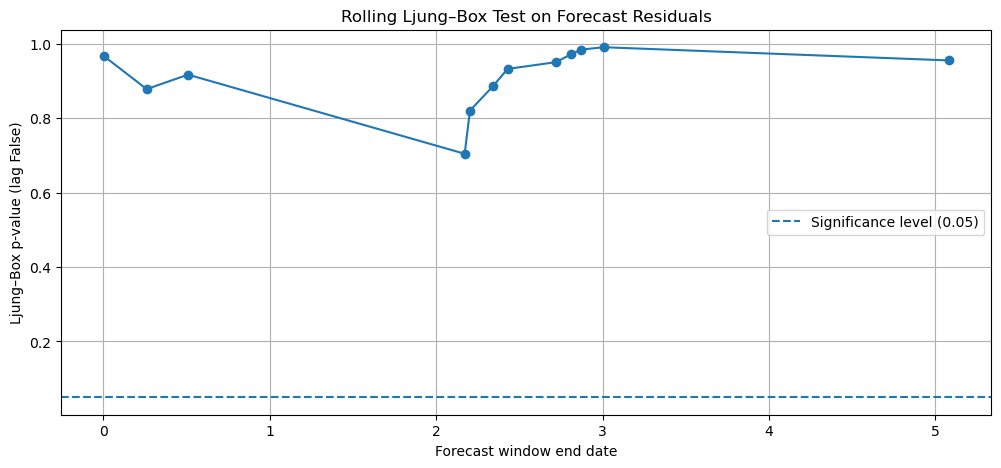

In [24]:
plot_sarimax_results(
    train=train,
    test=test,
    forecast=forecast,
    results=results,
    order=order,
    seasonal_order=seasonal_order,
    rmse=rmse,
    mae=mae,
)

In [25]:
best_info, scores_df = select_best_sarima_cv(
    df=data,
    target=target,
    candidates=candidates,
    train_years=8,
    forecast_months=24,
    test_start_year=1995,
    exog=None,
    metric="rmse",
    use="avg",
    verbose=True,
)

cv = best_info["cv_results"]



01. SARIMA(0,0,0)(0,0,0,12) - avg RMSE=1.9470, avg MAE=1.4856
02. SARIMA(0,0,0)(0,0,2,12) - avg RMSE=424.4802, avg MAE=230.4102
03. SARIMA(0,0,0)(2,0,0,12) - avg RMSE=1.6918, avg MAE=1.3374
04. SARIMA(0,0,0)(2,0,2,12) - avg RMSE=18712.6121, avg MAE=10484.2187
05. SARIMA(0,0,1)(0,0,0,12) - avg RMSE=1.9399, avg MAE=1.4816
06. SARIMA(0,0,1)(0,0,2,12) - avg RMSE=1204.1099, avg MAE=661.4101
07. SARIMA(0,0,1)(2,0,0,12) - avg RMSE=1.6953, avg MAE=1.3463
08. SARIMA(0,0,1)(2,0,2,12) - avg RMSE=20787.8658, avg MAE=11888.4994
09. SARIMA(0,0,2)(0,0,0,12) - avg RMSE=1.9381, avg MAE=1.4817
10. SARIMA(0,0,2)(0,0,2,12) - avg RMSE=965.0897, avg MAE=535.3315
11. SARIMA(0,0,2)(2,0,0,12) - avg RMSE=1.6894, avg MAE=1.3366
12. SARIMA(0,0,2)(2,0,2,12) - avg RMSE=104.4495, avg MAE=46.6899
13. SARIMA(1,0,0)(0,0,0,12) - avg RMSE=1.9377, avg MAE=1.4797
14. SARIMA(1,0,0)(0,0,2,12) - avg RMSE=1406.5415, avg MAE=685.2659
15. SARIMA(1,0,0)(2,0,0,12) - avg RMSE=1.6949, avg MAE=1.3474
16. SARIMA(1,0,0)(2,0,2,12) - avg

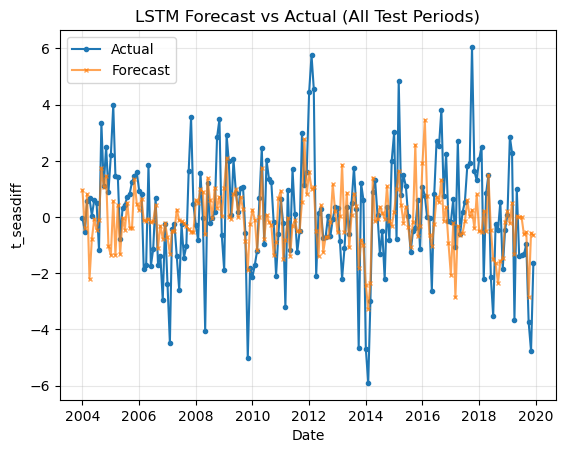

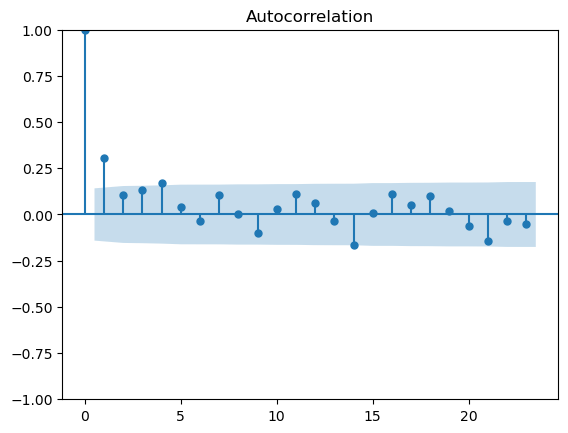

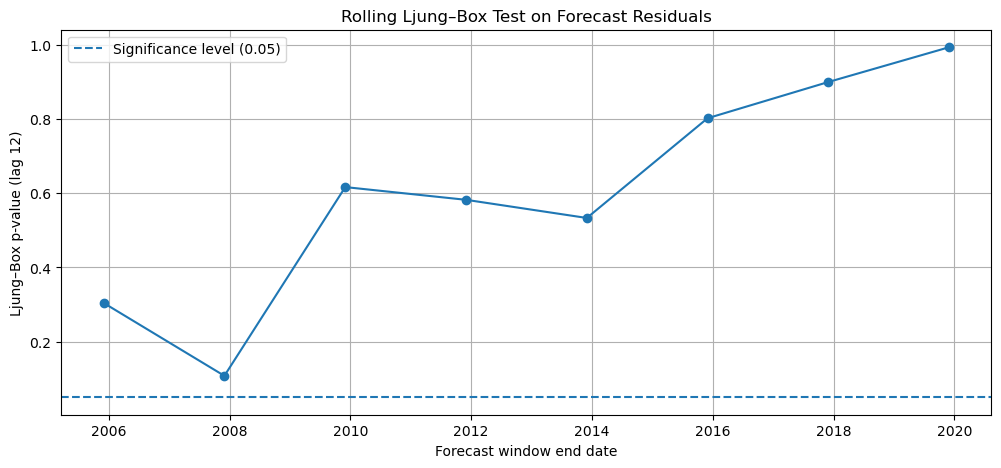

<Figure size 640x480 with 0 Axes>

In [26]:
from models import _plot_lstm_cv_results


cv = best_info["cv_results"]  


_plot_lstm_cv_results(
    df=data,
    target=target,
    split_metrics=cv.get("split_metrics", []),  
    forecasts=cv.get("forecasts", []),
    actuals=cv.get("actuals", []),
    forecast_months=24,
    residuals=cv.get("residuals", []),
    lb=pd.DataFrame(cv.get("lb_results", [])),
)

In [27]:
best_info, scores_df = select_best_sarima_cv(
    df=data,
    target=target,
    candidates=candidates,
    train_years=8,
    forecast_months=24,
    test_start_year=1995,
    exog=exog,
    metric="rmse",
    use="overall",
    verbose=True,
)



01. SARIMA(0,0,0)(0,0,0,12) - overall RMSE=1.6046, overall MAE=1.2637
02. SARIMA(0,0,0)(0,0,2,12) - overall RMSE=48609658.6614, overall MAE=9238901.0509
03. SARIMA(0,0,0)(2,0,0,12) - overall RMSE=1.5389, overall MAE=1.2326
04. SARIMA(0,0,0)(2,0,2,12) - overall RMSE=6230.1530, overall MAE=1640.0318
05. SARIMA(0,0,1)(0,0,0,12) - overall RMSE=1.6122, overall MAE=1.2652
06. SARIMA(0,0,1)(0,0,2,12) - overall RMSE=7369.3288, overall MAE=904.1762
07. SARIMA(0,0,1)(2,0,0,12) - overall RMSE=1.5428, overall MAE=1.2411
08. SARIMA(0,0,1)(2,0,2,12) - overall RMSE=17939.4463, overall MAE=4700.6824
09. SARIMA(0,0,2)(0,0,0,12) - overall RMSE=1.6162, overall MAE=1.2651
10. SARIMA(0,0,2)(0,0,2,12) - overall RMSE=447187744.8145, overall MAE=70225660.9718
11. SARIMA(0,0,2)(2,0,0,12) - overall RMSE=1.5473, overall MAE=1.2368
12. SARIMA(0,0,2)(2,0,2,12) - overall RMSE=6431.7017, overall MAE=1786.3742
13. SARIMA(1,0,0)(0,0,0,12) - overall RMSE=1.6101, overall MAE=1.2592
14. SARIMA(1,0,0)(0,0,2,12) - overall 

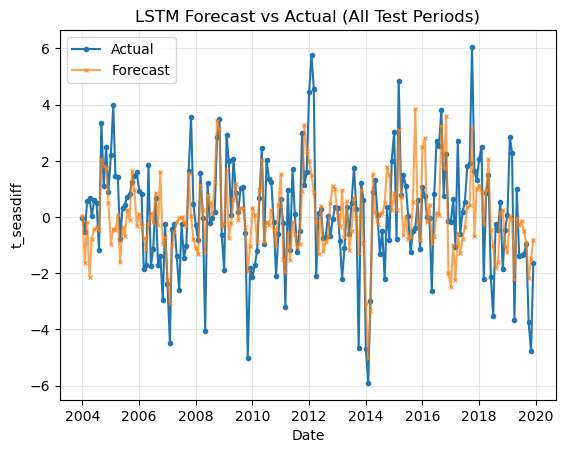

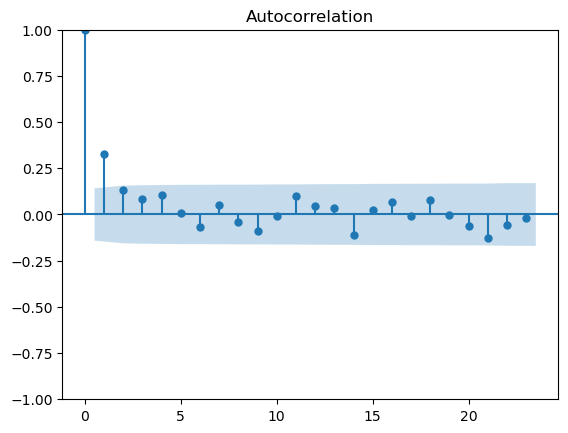

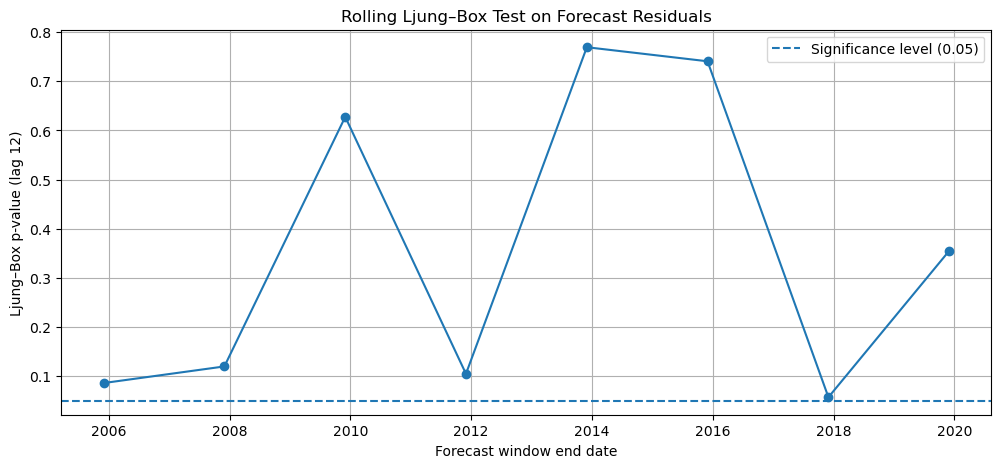

<Figure size 640x480 with 0 Axes>

In [28]:
cv = best_info["cv_results"]  


_plot_lstm_cv_results(
    df=data,
    target=target,
    split_metrics=cv.get("split_metrics", []),  
    forecasts=cv.get("forecasts", []),
    actuals=cv.get("actuals", []),
    forecast_months=24,
    residuals=cv.get("residuals", []),
    lb=pd.DataFrame(cv.get("lb_results", [])),
)

# LSTMs

In [29]:
res = lstm_grid_search_cv(data, 'tdiff', train_years=8, forecast_months=24, test_start_year=1996, epochs=60, verbose=0, param_grid={
    'exog': [['lagged_tmed', 'lagged_tmin', 'lagged_prec', 'lagged_tmax'], ['lagged_tmin', 'lagged_prec', 'lagged_tmax'], ['lagged_tmed', 'lagged_prec'], ['lagged_tmin', 'lagged_prec', 'lagged_tmax']],
    'lr': [0.001],
    'hidden_size': [50, 25, 100],
    'num_layers': [1, 2],
    'dropout': [0.1, 0.2, 0.3]
    
})

In [30]:
print_grid_search_results(res['results'], res['best_overall_score'], res['best_overall_results'], res['best_overall_params'],res['best_avg_score'], res['best_avg_results'], res['best_avg_params'],res['best_last_fold_score'], res['best_last_fold_results'], res['best_last_fold_params'])


GRID SEARCH COMPLETE

BEST MODEL BY OVERALL RMSE (concatenated predictions)
Overall RMSE: inf


TypeError: 'NoneType' object is not subscriptable

In [ ]:
results = lstm_time_series_cv(
    df=data,
    target='tdiff',
    train_years=8,
    forecast_months=24,
    test_start_year=1996,
    exog=['lagged_tmed_24', 'lagged_tmin_24', 'lagged_prec_24', 'lagged_tmax_24', 'lagged_tdiff_24'],  
    seq_length=24,
    epochs=60,
    batch_size=32,
    lr=0.001,
    hidden_size=100,
    num_layers=1,
    dropout=0.2,
    plot=True,
)

In [ ]:
results = lstm_time_series_cv(
    df=data,
    target='tdiff',
    train_years=8,
    forecast_months=24,
    test_start_year=1996,
    exog=['lagged_tmed_12', 'lagged_tmin_12', 'lagged_prec_12', 'lagged_tmax_12', 'lagged_tdiff_12'], 
    seq_length=24,
    epochs=60,
    batch_size=32,
    lr=0.001,
    hidden_size=25,
    num_layers=2,
    dropout=0.2,
    plot=True,
)

In [ ]:
results = lstm_time_series_cv(
    df=data,
    target='tdiff',
    train_years=8,
    forecast_months=24,
    test_start_year=1996,
    exog=['lagged_tmed_1', 'lagged_tmin_1', 'lagged_prec_1', 'lagged_tmax_1', 'lagged_tdiff_1', 'lagged_tmed_12', 'lagged_tmin_12', 'lagged_prec_12', 'lagged_tmax_12', 'lagged_tdiff_12' ], 
    seq_length=24,
    epochs=60,
    batch_size=32,
    lr=0.001,
    hidden_size=25,
    num_layers=2,
    dropout=0.2,
    plot=True,
)

In [ ]:
results = lstm_time_series_cv(
    df=data,
    target='tdiff',
    train_years=8,
    forecast_months=24,
    test_start_year=2010,
    exog=['lagged_tmed', 'lagged_tmin', 'lagged_prec', 'lagged_tmax', 'lagged_tdiff'], 
    seq_length=24,
    epochs=60,
    batch_size=32,
    lr=0.001,
    hidden_size=25,
    num_layers=2,
    dropout=0.2,
    plot=True,
)

In [ ]:
results = lstm_time_series_cv(
    df=data,
    target='tdiff',
    train_years=8,
    forecast_months=24,
    test_start_year=2010,
    exog=['lagged_tmin_24', 'lagged_prec_24', 'lagged_tmax_24', 'lagged_tdiff_24'],  
    seq_length=24,
    epochs=60,
    batch_size=32,
    lr=0.001,
    hidden_size=100,
    num_layers=1,
    dropout=0.2,
    plot=True,
)